# 08 · 完整專案與部署

把前七課全部串起來，在 **FashionMNIST**（衣服圖片）上訓練一個完整的 CNN 分類器，並學會**存檔、載入、部署**——讓模型走出 notebook，真正用起來。這是深度學習模組的收尾。

## 學習目標

- 串起完整流程：資料 → CNN（含 dropout）→ 訓練/驗證 → 評估
- 用 `torch.save` / `load_state_dict` 存檔與載入模型
- 認識部署選項（ONNX、TF.js）——呼應本站用 TF.js 在瀏覽器跑模型的遊戲 AI

## 1. 資料：FashionMNIST

跟 MNIST 同格式（28×28、10 類），但內容是 T 恤、鞋子、包包等——比數字更有挑戰。

  0%|          | 0.00/26.4M [00:00<?, ?B/s]

  0%|          | 32.8k/26.4M [00:00<02:36, 168kB/s]

  0%|          | 65.5k/26.4M [00:00<03:27, 127kB/s]

  0%|          | 131k/26.4M [00:00<02:12, 199kB/s] 

  1%|          | 229k/26.4M [00:00<01:28, 296kB/s]

...

 70%|███████   | 3.11M/4.42M [00:02<00:00, 2.97MB/s]

100%|██████████| 4.42M/4.42M [00:02<00:00, 5.05MB/s]

100%|██████████| 4.42M/4.42M [00:02<00:00, 2.10MB/s]

  0%|          | 0.00/5.15k [00:00<?, ?B/s]

100%|██████████| 5.15k/5.15k [00:00<00:00, 2.50MB/s]

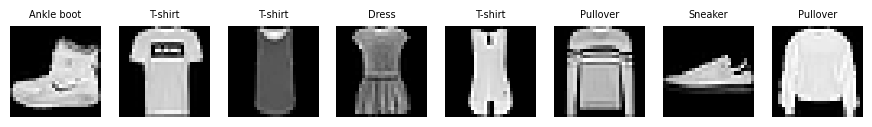

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
tfm = transforms.ToTensor()
train = Subset(datasets.FashionMNIST("data", train=True, download=True, transform=tfm), range(10000))
test = Subset(datasets.FashionMNIST("data", train=False, download=True, transform=tfm), range(2000))
classes = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
           "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
train_loader = DataLoader(train, batch_size=64, shuffle=True)
test_loader = DataLoader(test, batch_size=256)

fig, axes = plt.subplots(1, 8, figsize=(11, 1.8))
for ax, (img, label) in zip(axes, train):
    ax.imshow(img.squeeze(), cmap="gray"); ax.set_title(classes[label], fontsize=7); ax.axis("off")
plt.show()

## 2. 訓練一個完整的 CNN

In [2]:
model = nn.Sequential(
    nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
    nn.Flatten(), nn.Dropout(0.3),
    nn.Linear(64 * 7 * 7, 128), nn.ReLU(),
    nn.Linear(128, 10),
).to(device)

opt = torch.optim.Adam(model.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()

def accuracy(loader):
    model.eval(); c = 0; n = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            c += (model(xb).argmax(1) == yb).sum().item(); n += len(yb)
    return c / n

for epoch in range(5):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad(); crit(model(xb), yb).backward(); opt.step()
    print(f"epoch {epoch + 1}: test acc = {accuracy(test_loader):.1%}")

epoch 1: test acc = 78.5%


epoch 2: test acc = 80.8%


epoch 3: test acc = 84.9%


epoch 4: test acc = 87.0%


epoch 5: test acc = 88.9%


## 3. 存檔與載入

訓練好的模型要能存下來、之後直接載入用，不必重訓。慣例是只存 `state_dict`（參數）。

In [3]:
# 存檔
torch.save(model.state_dict(), "fashion_cnn.pt")
print("已儲存 fashion_cnn.pt")

# 載入到一個結構相同的新模型
import copy
fresh = copy.deepcopy(model)            # 同樣的結構
fresh.load_state_dict(torch.load("fashion_cnn.pt"))
fresh.eval()
print(f"重新載入後的測試準確率：{accuracy(test_loader):.1%}  (應與訓練後一致)")

已儲存 fashion_cnn.pt


重新載入後的測試準確率：88.9%  (應與訓練後一致)


## 4. 部署：讓模型走出 notebook

訓練只是第一步，要用起來得**部署**。常見路線：

- **ONNX**：`torch.onnx.export(model, sample, "model.onnx")` 匯出成跨框架的標準格式，可在伺服器、行動裝置、瀏覽器執行。
- **TF.js**：把模型轉成 TensorFlow.js，**直接在瀏覽器跑、零後端**——本站的遊戲 AI agent 就是用這條路（見 `/game` 的強化學習對手）。流程是 PyTorch →（ONNX）→ TensorFlow → TF.js。
- **API 服務**：用 FastAPI 等包成推論 API。

```python
# ONNX 匯出範例（在 Colab 可 pip install onnx 後執行）
sample = torch.randn(1, 1, 28, 28, device=device)
torch.onnx.export(model, sample, "model.onnx", input_names=["image"], output_names=["logits"])
```

## 小結：深度學習的完整流程

1. **資料** → `DataLoader` 分批
2. **模型** → CNN + dropout，搬上 `device`
3. **訓練/評估** → 訓練迴圈 + 逐輪看測試準確率
4. **存檔** → `torch.save(state_dict)`，`load_state_dict` 載回
5. **部署** → ONNX / TF.js / API

你已經走完從 tensor 到部署的完整旅程！

## 練習（綜合）

1. 把訓練資料加到全部 6 萬筆、epoch 加到 10，FashionMNIST 準確率能到多少？
2. 加上 data augmentation（`transforms.RandomHorizontalFlip()`），測試準確率有提升嗎？
3. 挑戰：在 Colab 把模型匯出成 ONNX，再研究怎麼轉成 TF.js 放到網頁上跑。

下一個學習階段是 **大型語言模型（LLM）**——我們會從零打造一個迷你 GPT。